In [1]:
# Load LeafletSC 
import LeafletSC
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

import os
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# turn this into AnnData object 
import anndata as ad
from scipy.sparse import csr_matrix
from scipy.sparse import coo_matrix

# Define path that contains junction files
juncs_path = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/"

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
gtf_file = "/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/reference-genome/gencode.vM34.basic.annotation.gtf" 
metadata = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/data/SraRunTable_mouse_brain.txt"

The junctions are loaded from the following path: /gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet
The files in the path are: ['SRR1033791_barcodes.txt', 'SRR1033788_junctions_with_barcodes.bed', 'SRR1033787_barcodes.txt', 'SRR1033796_barcodes.txt', 'SRR1033796_junctions_with_barcodes.bed', 'SRR1033785_junctions_with_barcodes.bed', 'SRR1033784_barcodes.txt', 'SRR1033789_junctions_with_barcodes.bed', 'SRR1033784_junctions_with_barcodes.bed', 'SRR1033793_junctions_with_barcodes.bed', 'SRR1033783_barcodes.txt', 'SRR1033793_barcodes.txt', 'SRR1033791_junctions.bed', 'SRR1033789_junctions.bed', 'SRR1033794_barcodes.txt', 'SRR1033786_barcodes.txt', 'SRR1033797_barcodes.txt', 'SRR1033795_junctions.bed', 'SRR1033799_junctions.bed', 'SRR1033792_barcodes.txt', 'SRR1033798_barcodes.txt', 'SRR1033786_junctions.bed', 'SRR1033789_barcodes.txt', 'SRR1033796_junctions.bed', 'SRR1033795_junctions_with_barcodes.bed', 'SRR1033794_junctions.bed', 'SRR1033792_junctions_with_barcodes.b

In [2]:
# list the first 5 files or folders in juncs_path
all_files = os.listdir(juncs_path)
print(all_files)

['SRR1033791_barcodes.txt', 'SRR1033788_junctions_with_barcodes.bed', 'SRR1033787_barcodes.txt', 'SRR1033796_barcodes.txt', 'SRR1033796_junctions_with_barcodes.bed', 'SRR1033785_junctions_with_barcodes.bed', 'SRR1033784_barcodes.txt', 'SRR1033789_junctions_with_barcodes.bed', 'SRR1033784_junctions_with_barcodes.bed', 'SRR1033793_junctions_with_barcodes.bed', 'SRR1033783_barcodes.txt', 'SRR1033793_barcodes.txt', 'SRR1033791_junctions.bed', 'SRR1033789_junctions.bed', 'SRR1033794_barcodes.txt', 'SRR1033786_barcodes.txt', 'SRR1033797_barcodes.txt', 'SRR1033795_junctions.bed', 'SRR1033799_junctions.bed', 'SRR1033792_barcodes.txt', 'SRR1033798_barcodes.txt', 'SRR1033786_junctions.bed', 'SRR1033789_barcodes.txt', 'SRR1033796_junctions.bed', 'SRR1033795_junctions_with_barcodes.bed', 'SRR1033794_junctions.bed', 'SRR1033792_junctions_with_barcodes.bed', 'SRR1033784_junctions.bed', 'SRR1033790_barcodes.txt', 'SRR1033799_barcodes.txt', 'SRR1033794_junctions_with_barcodes.bed', 'SRR1033783_junctio

In [3]:
import os

all_junc_files = []

# List all subdirectories in juncs_path
all_files = os.listdir(juncs_path)
        
# Keep only files that end with *junctions_with_barcodes.bed
junc_files = [x for x in all_files if x.endswith('junctions_with_barcodes.bed')]

# Construct full paths and include the subdirectory information
junc_files = [os.path.join(juncs_path, x) for x in junc_files]

# Add these files to the main list
all_junc_files.extend(junc_files)

# Print the resulting paths
print("Final paths with correct subdirectory context:")
print(all_junc_files)

Final paths with correct subdirectory context:
['/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033788_junctions_with_barcodes.bed', '/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033796_junctions_with_barcodes.bed', '/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033785_junctions_with_barcodes.bed', '/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033789_junctions_with_barcodes.bed', '/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033784_junctions_with_barcodes.bed', '/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033793_junctions_with_barcodes.bed', '/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033795_junctions_with_barcodes.bed', '/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033792_junctions_with_barcodes.bed', '/gpfs/commons/projects/knowles_singlecell_splic

In [4]:
# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "/mouse_brain_bulk_clean_celltypes"
junc_bed_file= output_path + "/mouse_brain_bulk_clean_celltypes.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.01 
min_junc_reads = 50
min_num_cells_wjunc=2
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*with_barcodes.bed" # depends on how you ran regtools 

In [5]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc, filter_shared_ss=True, 
                       run_notebook = True)

100%|██████████| 17/17 [00:09<00:00,  1.89it/s]


The number of junctions before filtering for num_cells_wjunc 804954
The number of junctions after filtering for num_cells_wjunc 403404
The number of junctions after filtering for intron length is 403404
Making gr object from all junctions across all cell types
The number of junctions after filtering by min_junc_reads 170372
The gtf file you provided is /gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/reference-genome/gencode.vM34.basic.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'mgi_id', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_number', 'exon_id', 'protein_id', 'ccdsid', 'ont']


Reading gtf file took 62.97 seconds
The number of unique exons is 327966
The number of unique transcript ids is 83005
The number of unique gene ids is 57119
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 152723
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 133840
+--------------+-----------+-----------+--------------+-------+
| Chromosome   | Start     | End       | Strand       | +10   |
| (category)   | (int64)   | (int64)   | (category)   | ...   |
|--------------+-----------+-----------+--------------+-------|
| 1            | 100297609 | 100297782 | +            | ...   |
| 1            | 100297609 | 100297782 | +            | ...   |
| 1            | 100297953 | 100306775 | +            | ...   |
| 1            | 100297953 | 100306775 | +            | ...   |
| .

In [6]:
# load bed file 
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

      chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
25558     X     168102.586   168103.110      -            524           371   
25557     X     168102.586   168102.971      -            385           992   

          Start_b       End_b               exon_id  
25558  168102.433  168102.586  ENSMUSE00000935665.2  
25557  168102.433  168102.586  ENSMUSE00000935665.2  
The junction of interest is X_168102586_168103110


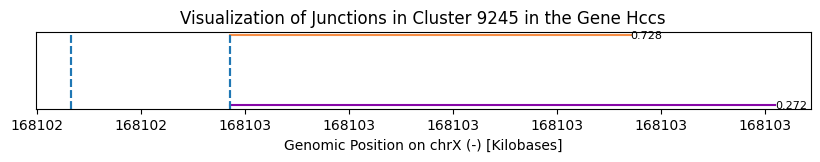

In [7]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [8]:
# get average number of junctions per cluster here 
avg_juncs_per_cluster = dat_vis.groupby("Cluster").size().mean()
print("The average number of junctions per cluster is: " + str(avg_juncs_per_cluster))

The average number of junctions per cluster is: 3.0964641670621735


In [9]:
intron_clusters = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389//mouse_brain_bulk_clean_celltypes_50_500000_3_20240909_single_cell.gz" # path to the intron clusters file
output_file = output_path + "mouse_brain_bulk_clean_celltypes_clusters" # what you want to name the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
# metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [10]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, None)

The intron clusters file you provided is /gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389//mouse_brain_bulk_clean_celltypes_50_500000_3_20240909_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


171it [00:09, 18.89it/s]


Done processing intron clusters
The number of intron clusters evaluated is 18958
The number of junctions evaluated is 69273
The number of cells evaluated is 17
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 17
The number of cells per cell type is:
cell_type
/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033783_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033784_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033785_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033786_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR1033787_junctions_with_barcodes.bed    1
/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/Leaflet/SRR10

In [11]:
model_input_data = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/mouse_brain_bulk_clean_celltypes_clusters.h5"
summarized_data = pd.read_hdf(model_input_data, 'df')
print(summarized_data.head())

                                             cell_id  Cluster  Cluster_Counts  \
0  SRR1033783_/gpfs/commons/projects/knowles_sing...        3             109   
1  SRR1033783_/gpfs/commons/projects/knowles_sing...        3             109   
2  SRR1033783_/gpfs/commons/projects/knowles_sing...        3             109   
3  SRR1033783_/gpfs/commons/projects/knowles_sing...        4             153   
4  SRR1033783_/gpfs/commons/projects/knowles_sing...        4             153   

           junction_id                gene_id  junc_count  \
0  1_36559308_36559599  ENSMUSG00000001138.14          38   
1  1_36559308_36559899  ENSMUSG00000001138.14           2   
2  1_36559769_36559899  ENSMUSG00000001138.14          69   
3  1_36560920_36563114  ENSMUSG00000001138.14          16   
4  1_36560920_36564246  ENSMUSG00000001138.14         112   

                                           cell_type  junc_ratio  \
0  /gpfs/commons/projects/knowles_singlecell_spli...    0.348624   
1  /gpfs/c

In [12]:
# combine with info from metadata
metadata_df = pd.read_csv(metadata)
metadata_df["cell_id"] = metadata_df["Run"]
metadata_df = metadata_df[["cell_id", "source_name", "cell_type"]]

In [13]:
all_cell_ids = summarized_data.cell_id

# clean up each cell_id using .str.split("_/gpfs")[0]
all_cell_ids_clean = [x.split("_/")[0] for x in all_cell_ids]
summarized_data["cell_id_clean"] = all_cell_ids_clean
# remove cell_id columb from summarized_data 
summarized_data = summarized_data.drop(columns=["cell_id", "cell_type"])# rename cell_id_clean to cell_id
summarized_data = summarized_data.rename(columns={"cell_id_clean": "cell_id"})

In [14]:
summarized_data = summarized_data.merge(metadata_df, on="cell_id")

In [15]:
summarized_data

,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,junc_ratio,cell_id_index,junction_id_index,cell_id,source_name,cell_type
0,3,109,1_36559308_36559599,ENSMUSG00000001138.14,38,0.348624,0,30998,SRR1033783,cerebral cortex,Astrocyte
1,3,109,1_36559308_36559899,ENSMUSG00000001138.14,2,0.018349,0,30999,SRR1033783,cerebral cortex,Astrocyte
2,3,109,1_36559769_36559899,ENSMUSG00000001138.14,69,0.633028,0,31000,SRR1033783,cerebral cortex,Astrocyte
3,4,153,1_36560920_36563114,ENSMUSG00000001138.14,16,0.104575,0,31001,SRR1033783,cerebral cortex,Astrocyte
4,4,153,1_36560920_36564246,ENSMUSG00000001138.14,112,0.732026,0,31002,SRR1033783,cerebral cortex,Astrocyte
...,...,...,...,...,...,...,...,...,...,...,...
853084,44164,75,Y_1266693_1267102,ENSMUSG00000069045.12,39,0.520000,16,69247,SRR1033799,whole cortex,NaN
853085,44164,75,Y_1266693_1269704,ENSMUSG00000069045.12,2,0.026667,16,69248,SRR1033799,whole cortex,NaN
853086,44164,75,Y_1267188_1269704,ENSMUSG00000069045.12,34,0.453333,16,69249,SRR1033799,whole cortex,NaN
853087,44166,78,Y_1279578_1280309,ENSMUSG00000069045.12,46,0.589744,16,69250,SRR1033799,whole cortex,NaN


In [16]:
# Prep andata object 
cell_vars = summarized_data[['cell_id', 'cell_id_index', 'cell_type', 'source_name']].drop_duplicates()
# Specify the junction variables

junction_vars = summarized_data[['Cluster', 'junction_id', 'gene_id', 'junction_id_index']].drop_duplicates()
# Create sparse matrices directly using cell_id_index, junction_id_index, and counts
n_cells = cell_vars['cell_id_index'].nunique()
n_junctions = junction_vars['junction_id_index'].nunique()

In [17]:
test=summarized_data[["cell_id_index", "Cluster_Counts", "Cluster"]].merge(junction_vars, on=['Cluster'], how='right').drop_duplicates()

In [18]:
junction_vars

,Cluster,junction_id,gene_id,junction_id_index
0,3,1_36559308_36559599,ENSMUSG00000001138.14,30998
1,3,1_36559308_36559899,ENSMUSG00000001138.14,30999
2,3,1_36559769_36559899,ENSMUSG00000001138.14,31000
3,4,1_36560920_36563114,ENSMUSG00000001138.14,31001
4,4,1_36560920_36564246,ENSMUSG00000001138.14,31002
...,...,...,...,...
841060,34964,14_19121719_19137061,ENSMUSG00000096574.9,14078
841068,34965,14_18429549_18433907,ENSMUSG00000096775.2,14047
841071,34966,14_18640230_18654751,ENSMUSG00000096793.9,14050
842058,35829,15_79100424_79106024,ENSMUSG00000075555.14,17792


In [19]:
# Sparse matrix for junc_count
junc_count_sparse = coo_matrix(
    (summarized_data['junc_count'], 
     (summarized_data['cell_id_index'], summarized_data['junction_id_index'])),
    shape=(n_cells, n_junctions)
)

# Sparse matrix for Cluster_Counts 
# Here cell-junction pairs that are zero while cell-cluster (to which junction belongs to is not zero) 
# Those indices have to have cluster counts in this matrix 
cluster_count_sparse = coo_matrix(
    (test['Cluster_Counts'], 
     (test['cell_id_index'], test['junction_id_index'])),
    shape=(n_cells, n_junctions)
)

In [20]:
# Create an AnnData object with junc_count_sparse
adata = ad.AnnData(X=junc_count_sparse, obs=cell_vars.set_index('cell_id_index'), var=junction_vars.set_index('junction_id_index'))

# Add the second sparse matrix to the AnnData object as a new layer
adata.layers["Junction_Counts"] = junc_count_sparse
adata.layers["Cluster_Counts"] = cluster_count_sparse

adata.var.index = adata.var.index.astype(int)
adata.var.sort_index(ascending=True, inplace=True)

adata.obs.index = adata.obs.index.astype(int)
adata.obs.sort_index(ascending=True, inplace=True)

# Convert the sparse matrix in adata.X to CSR format
adata.X = csr_matrix(adata.X)

# If you have other sparse matrices in layers, convert them as well
adata.layers["Junction_Counts"] = csr_matrix(adata.layers["Junction_Counts"])
# If you have other sparse matrices in layers, convert them as well
adata.layers["Cluster_Counts"] = csr_matrix(adata.layers["Cluster_Counts"])

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [32]:
import random
indloc = random.randint(0, n_junctions)
j_count = summarized_data.iloc[indloc].junc_count
clust_count = summarized_data.iloc[indloc].Cluster_Counts
cell_ind = summarized_data.iloc[indloc].cell_id_index
j_ind = summarized_data.iloc[indloc].junction_id_index
gene_id = summarized_data.iloc[indloc].gene_id
junc_id = summarized_data.iloc[indloc].junction_id

print(j_count, clust_count)
print(adata.layers["Junction_Counts"].toarray()[cell_ind, j_ind], adata.layers["Cluster_Counts"].toarray()[cell_ind, j_ind])

print(junc_id, gene_id)
print(adata.var.iloc[j_ind])

2 285
2 285
2_51928281_51937442 ENSMUSG00000053475.6
Cluster                        4268
junction_id     2_51928281_51937442
gene_id        ENSMUSG00000053475.6
Name: 37528, dtype: object


In [22]:
# Save the AnnData object to a file in HDF5 format
adata.write_h5ad('/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/LeafletFA/mouse_brain_rnaseq_clean_cell_types.h5ad', compression='gzip')

... storing 'cell_type' as categorical
... storing 'source_name' as categorical
... storing 'gene_id' as categorical


In [23]:
adata.var.Cluster.value_counts()

Cluster
44122    73
30297    72
19437    36
22430    32
14335    31
         ..
31006     2
40319     2
20667     2
31781     2
16152     2
Name: count, Length: 18958, dtype: int64

In [48]:
import numpy as np

# Extract junction counts and cluster counts
junction_counts = adata.layers["Junction_Counts"].toarray()  # Convert sparse to dense if necessary
cluster_counts = adata.layers["Cluster_Counts"].toarray()

adata.layers["junc_ratio"] = np.divide(junction_counts, cluster_counts, out=np.zeros_like(junction_counts, dtype=float), where=(cluster_counts != 0))


In [49]:
adata.layers["junc_ratio"]

array([[0.52      , 0.        , 0.48      , ..., 0.53448276, 0.01724138,
        0.44827586],
       [0.50649351, 0.        , 0.49350649, ..., 0.45652174, 0.0326087 ,
        0.51086957],
       [0.46268657, 0.05970149, 0.47761194, ..., 0.6       , 0.        ,
        0.4       ],
       ...,
       [0.51282051, 0.        , 0.48717949, ..., 0.58139535, 0.        ,
        0.41860465],
       [0.61111111, 0.        , 0.38888889, ..., 0.5       , 0.        ,
        0.5       ],
       [0.5       , 0.        , 0.5       , ..., 0.5       , 0.        ,
        0.5       ]])

In [50]:
adata.obs

,cell_id,cell_type,source_name
cell_id_index,,,
0,SRR1033783,Astrocyte,cerebral cortex
1,SRR1033784,Astrocyte,cerebral cortex
2,SRR1033785,neuron,cerebral cortex
3,SRR1033786,neuron,cerebral cortex
4,SRR1033787,oligodendrocyte precursor cells,cerebral cortex
5,SRR1033788,oligodendrocyte precursor cells,cerebral cortex
6,SRR1033789,newly formed oligodendrocytes,cerebral cortex
7,SRR1033790,newly formed oligodendrocytes,cerebral cortex
8,SRR1033791,myelinating oligodendrocytes,cerebral cortex


In [55]:
import scanpy as sc

# Step 1: Perform PCA
sc.pp.pca(adata, n_comps=10, use_highly_variable=False, layer='junc_ratio')

# Step 2: Compute UMAP on the PCA-reduced data
sc.pp.neighbors(adata, n_pcs=10, use_rep='X_pca')
sc.tl.umap(adata)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


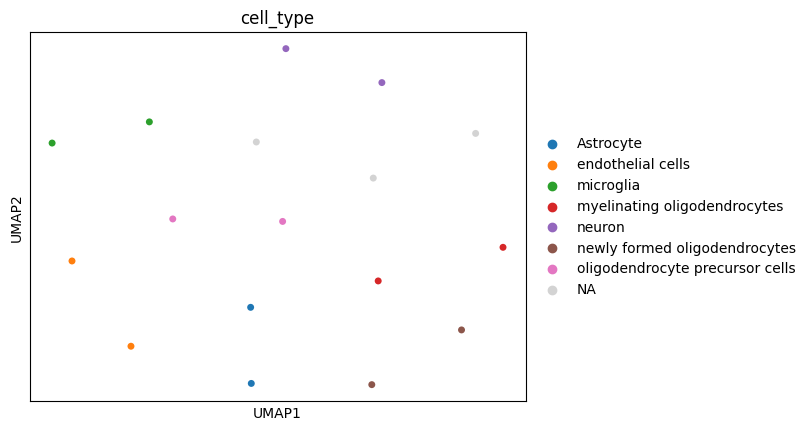

In [60]:
# Step 3: Plot UMAP and color by 'cell_type'
sc.pl.umap(adata, color='cell_type', size=100)

      chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
23989     9     114426.674   114427.772      -           1098           133   
23990     9     114426.898   114427.772      -            874          1390   
23988     9     114426.674   114426.862      -            188          1156   

          Start_b       End_b               exon_id  
23989  114426.546  114426.674  ENSMUSE00000330179.4  
23990  114426.862  114426.898  ENSMUSE00000330199.4  
23988  114426.546  114426.674  ENSMUSE00000330179.4  
The junction of interest is 9_114426898_114427772


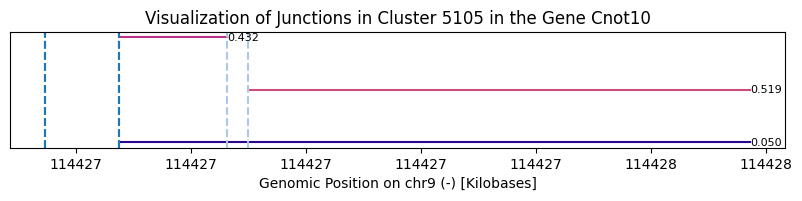

In [72]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)